In [2]:
import numpy as np
from glob import glob
import pandas as pd
import matplotlib.pyplot as plt
from as7341_calibrate import basic_counts, calibrated_raw
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression


In [3]:
CH = ['f1_415', 'f2_445', 'f3_480', 'f4_515', 'f5_555',
            'f6_590', 'f7_630', 'f8_680', 'clear', 'nir']

DATA = "../data/"
files = glob(f"{DATA}/*.csv")

df = pd.DataFrame()

for file in files:
      tdf = pd.read_csv(file)
      df = pd.concat([df,tdf])



### PAR regression - spectrally UNcalibrated `basic_counts` for whole dataset
Use the AS7341 raw channel converted to `basic_counts` to predict PAR measured with the golden reference;
`tia_par` (Li-250A) regressed on the 10 channels.

Total samples: 462
Training samples: 369, Testing samples: 93
Linear regression
  MAE : 14.63
  RMSE: 22.06
  R^2 : 0.9988
Coefficients: {'f1_415': 381.0492932011064, 'f2_445': 201.9854081305986, 'f3_480': -9.157353488338668, 'f4_515': 258.70916067994466, 'f5_555': -133.65133889492515, 'f6_590': 70.55856333948091, 'f7_630': 39.84180044994199, 'f8_680': -12.623817394118893, 'clear': 16.947405005859807, 'nir': -38.219397243779184}
Intercept: 5.369189197718697


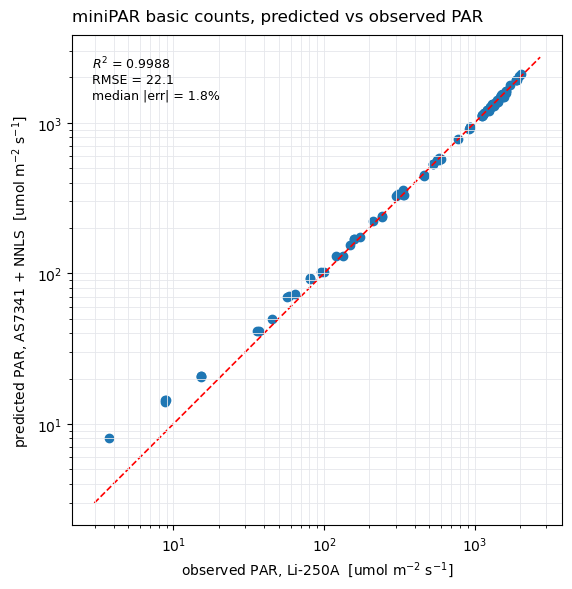

In [4]:


X = basic_counts(df)
Y = df.tia_par.to_numpy(float)

X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)


print("Total samples:", len(X))
print(f"Training samples: {len(X_train)}, Testing samples: {len(X_test)}")

# ---- Model ----
lin = LinearRegression()
lin.fit(X_train, y_train)

# ---- Predict + metrics ----
pred = lin.predict(X_test)

mae = mean_absolute_error(y_test, pred)
rmse = np.sqrt(mean_squared_error(y_test, pred))
r2 = r2_score(y_test, pred)

res = pred - y_test
mape = float(np.median(np.abs(res) / y_test) * 100)

print("Linear regression")
print(f"  MAE : {mae:.4g}")
print(f"  RMSE: {rmse:.4g}")
print(f"  R^2 : {r2:.4g}")
print("Coefficients:", dict(zip(CH, lin.coef_)))
print("Intercept:", lin.intercept_)



lim = (0.8 * min(Y.min(), pred[pred > 0].min()), 1.3 * max(Y.max(), pred.max()))

fig, ax = plt.subplots(figsize=(6.2, 6.0))
ax.scatter(y_test,pred)
ax.plot(lim, lim, color='r', lw=1.2, ls='--', zorder=1, label='1:1')
ax.set(xscale='log', yscale='log',
       xlabel='observed PAR, Li-250A  [umol m$^{-2}$ s$^{-1}$]',
       ylabel='predicted PAR, AS7341 + NNLS  [umol m$^{-2}$ s$^{-1}$]')
ax.set_title('miniPAR basic counts, predicted vs observed PAR', loc='left', pad=10)
ax.set_aspect('equal')
ax.grid(True, which='both', color='#e5e7eb', lw=0.6, zorder=0)
ax.annotate('$R^2$ = %.4f\nRMSE = %.1f\nmedian |err| = %.1f%%' % (r2, rmse, mape),
            xy=(0.04, 0.96), xycoords='axes fraction', va='top',
           fontsize=9)
fig.tight_layout()
plt.show()


### PAR regression - spectrally CALIBRATED `basic_counts` for whole dataset
Use the AS7341 raw channel converted to `basic_counts`, offset corrected and spectrally calibrated as described in AN000633 (§2.1, §2.2, §2.4) to predict PAR measured with the golden reference;
`tia_par` (Li-250A) regressed on the 10 calibrated channels.
This is to show that essentially the fitting can account for the spectral calibration, and do not needs to be done sequentially.

Total samples: 462
Training samples: 369, Testing samples: 93
Linear regression
  MAE : 14.64
  RMSE: 22.06
  R^2 : 0.9988
Coefficients: {'f1_415': 10.924000214965185, 'f2_445': 3.089891199773737, 'f3_480': -0.12294864623976433, 'f4_515': 4.08381526546024, 'f5_555': -2.3532156656570904, 'f6_590': 1.3337374847824803, 'f7_630': 0.8171288227393011, 'f8_680': -0.2975749559821554, 'clear': 0.5372994329662061, 'nir': -6.612943985007414}
Intercept: 7.8074864547064635


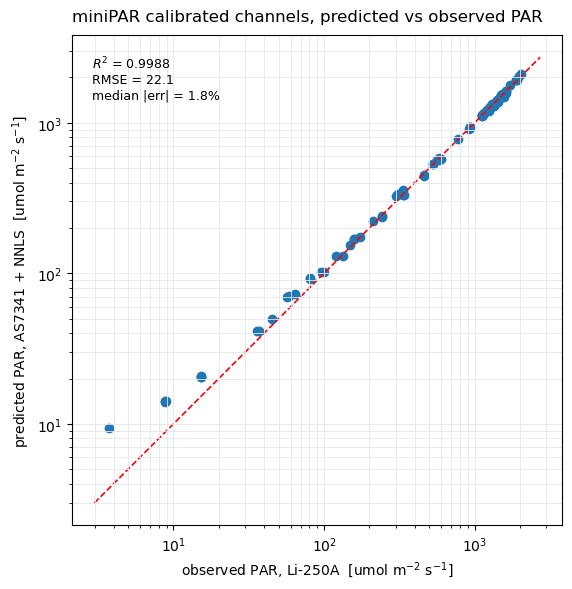

In [5]:
X = calibrated_raw(df) # use the spectrally calibrated
Y = df.tia_par.to_numpy(float)

X_train, X_test, y_train, y_test = train_test_split(X,Y, test_size=0.2, random_state=42)


print("Total samples:", len(X))
print(f"Training samples: {len(X_train)}, Testing samples: {len(X_test)}")

# ---- Model ----
lin = LinearRegression()
lin.fit(X_train, y_train)

# ---- Predict + metrics ----
pred = lin.predict(X_test)

mae = mean_absolute_error(y_test, pred)
rmse = np.sqrt(mean_squared_error(y_test, pred))
r2 = r2_score(y_test, pred)

res = pred - y_test
mape = float(np.median(np.abs(res) / y_test) * 100)

print("Linear regression")
print(f"  MAE : {mae:.4g}")
print(f"  RMSE: {rmse:.4g}")
print(f"  R^2 : {r2:.4g}")
print("Coefficients:", dict(zip(CH, lin.coef_)))
print("Intercept:", lin.intercept_)



lim = (0.8 * min(Y.min(), pred[pred > 0].min()), 1.3 * max(Y.max(), pred.max()))

fig, ax = plt.subplots(figsize=(6.2, 6.0))
ax.scatter(y_test,pred)
ax.plot(lim, lim, color='r', lw=1.2, ls='--', zorder=1, label='1:1')
ax.set(xscale='log', yscale='log',
       xlabel='observed PAR, Li-250A  [umol m$^{-2}$ s$^{-1}$]',
       ylabel='predicted PAR, AS7341 + NNLS  [umol m$^{-2}$ s$^{-1}$]')
ax.set_title('miniPAR calibrated channels, predicted vs observed PAR', loc='left', pad=10)
ax.set_aspect('equal')
ax.grid(True, which='both', color='#e5e7eb', lw=0.6, zorder=0)
ax.annotate('$R^2$ = %.4f\nRMSE = %.1f\nmedian |err| = %.1f%%' % (r2, rmse, mape),
            xy=(0.04, 0.96), xycoords='axes fraction', va='top',
           fontsize=9)
fig.tight_layout()
plt.show()

### PAR from the SUMMED calibrated channels — Example of doing it wrong.
Use the AS7341 raw channel converted to `basic_counts`, offset corrected and spectrally calibrated as described in AN000633 (§2.1, §2.2, §2.4) to predict PAR measured with the golden reference;
`tia_par` (Li-250A) regressed on the 10 corrected channels. 
Here by summing the different wavelength shows that the fit degrade by leaving less degree of freedom.


Total samples: 462
Training samples: 369, Testing samples: 93
Linear regression
  MAE : 128.7
  RMSE: 158.6
  R^2 : 0.9364
Coefficient: [0.88294368]
Intercept: 55.1634616682004


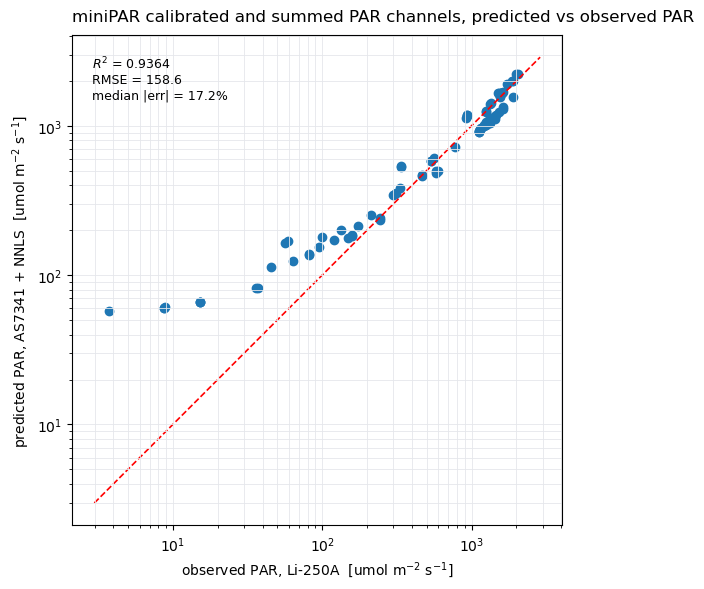

In [6]:

par = calibrated_raw(df)[['cal_f1_415', 'cal_f2_445', 'cal_f3_480', 'cal_f4_515', 'cal_f5_555',
       'cal_f6_590', 'cal_f7_630', 'cal_f8_680']].sum(axis=1) # use the spectrally calibrated and par like SUMMED channels 

X = par.to_numpy(float).reshape(-1,1)
Y = df.tia_par.to_numpy(float)

X_train, X_test, y_train, y_test = train_test_split(X,Y, test_size=0.2, random_state=42)


print("Total samples:", len(X))
print(f"Training samples: {len(X_train)}, Testing samples: {len(X_test)}")

# ---- Model ----
lin = LinearRegression()
lin.fit(X_train, y_train)

# ---- Predict + metrics ----
pred = lin.predict(X_test)

mae = mean_absolute_error(y_test, pred)
rmse = np.sqrt(mean_squared_error(y_test, pred))
r2 = r2_score(y_test, pred)

res = pred - y_test
mape = float(np.median(np.abs(res) / y_test) * 100)

print("Linear regression")
print(f"  MAE : {mae:.4g}")
print(f"  RMSE: {rmse:.4g}")
print(f"  R^2 : {r2:.4g}")
print("Coefficient:", lin.coef_)
print("Intercept:", lin.intercept_)



lim = (0.8 * min(y_test.min(), pred[pred > 0].min()),1.3 * max(y_test.max(), pred.max()))

fig, ax = plt.subplots(figsize=(6.2, 6.0))
ax.scatter(y_test,pred)
ax.plot(lim, lim, color='r', lw=1.2, ls='--', zorder=1, label='1:1')
ax.set(xscale='log', yscale='log',
       xlabel='observed PAR, Li-250A  [umol m$^{-2}$ s$^{-1}$]',
       ylabel='predicted PAR, AS7341 + NNLS  [umol m$^{-2}$ s$^{-1}$]')
ax.set_title('miniPAR calibrated and summed PAR channels, predicted vs observed PAR', loc='left', pad=10)
ax.set_aspect('equal')
ax.grid(True, which='both', color='#e5e7eb', lw=0.6, zorder=0)
ax.annotate('$R^2$ = %.4f\nRMSE = %.1f\nmedian |err| = %.1f%%' % (r2, rmse, mape),
            xy=(0.04, 0.96), xycoords='axes fraction', va='top',
           fontsize=9)
fig.tight_layout()
plt.show()

### Tier-2 selection: bounded visible channels, judged by coefficient stability

Refits `w` with **F1–F8 bounded ≥ 0** — `clear` and `nir` stay free, since they subtract
stray light and out-of-band leakage and a negative weight is physical for them — and picks
the vector on **how little it moves when the sample set changes**, not on R²/RMSE. With a
condition number around 450 on a daylight-dominated set, a vector can fit this data well
and still be arbitrary.

Reported per candidate, all under a **device-cluster bootstrap** (whole devices resampled,
because rows within a device are correlated):

* **direction spread** — angle of each draw from the centroid, after quotienting out overall
  scale (tier 3's slope absorbs it, so scale wobble costs nothing downstream);
* **IQR / ‖w‖₁** per channel — not IQR/|median|, which explodes for any coefficient resting
  on the bound;
* **pin rate** — fraction of draws landing exactly on 0, which tells you whether the bound
  is stabilising a channel or deleting it;
* **PAR spread by light type** — the same instability expressed in %, on a shape-normalised
  prototype spectrum per source family.

The closing λ scan tests whether shrinkage toward a smooth spectral prior keeps the pinned
channels alive without giving the stability back.

channels                        f1_41  f2_44  f3_48  f4_51  f5_55  f6_59  f7_63  f8_68  clear    nir
--- all coefficients free
    direction spread  : median 22.13 deg   p95 62.33 deg
    IQR / ||w||_1     :  0.293  0.104  0.094  0.136  0.111  0.037  0.010  0.027  0.007  0.006
    pinned at 0 (F1-F8):   0.00   0.00   0.00   0.00   0.00   0.00   0.00   0.00
    PAR spread by light type (%): daylight=0.4  led=0.6  office=1.0  gel=1.2  canopy=6.2
--- F1-F8 >= 0, clear/nir free
    direction spread  : median  5.56 deg   p95 23.88 deg
    IQR / ||w||_1     :  0.137  0.059  0.000  0.008  0.000  0.025  0.009  0.000  0.009  0.005
    pinned at 0 (F1-F8):   0.01   0.02   0.98   0.00   0.97   0.01   0.00   0.91
    PAR spread by light type (%): daylight=0.2  led=0.4  office=1.3  gel=1.1  canopy=2.4

full-data constrained w, normalised to f1:
   f1_41=1.000  f2_44=0.202  f3_48=0.000  f4_51=0.490  f5_55=0.000  f6_59=0.113  f7_63=0.141  f8_68=0.000  clear=0.053  nir=-0.103

--- F1-F8 >= 0 + shrink 

C:\Users\LudovicoCaracciolo\AppData\Local\Temp\ipykernel_33592\2383330910.py:209: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


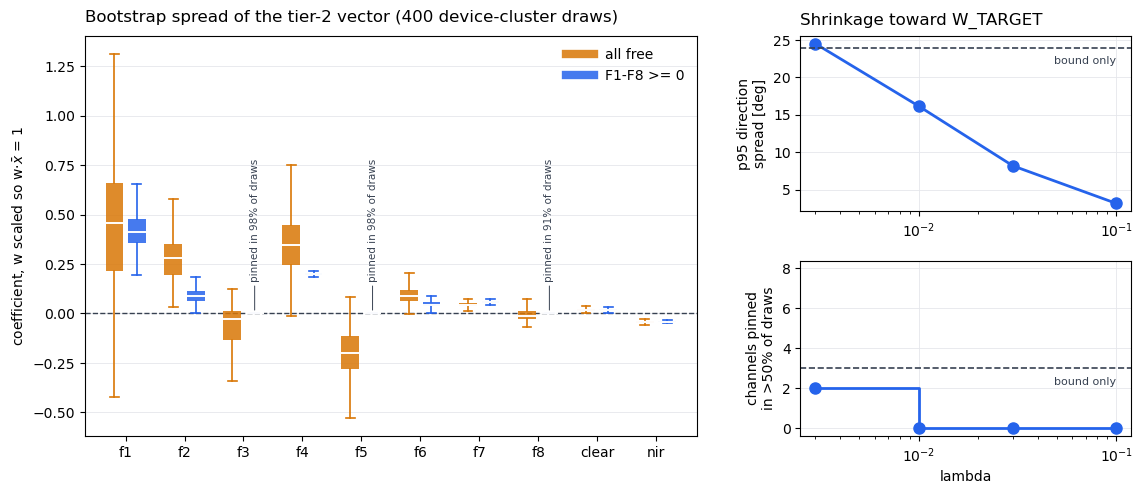

In [7]:
# =====================================================================================
# PAR fitting: visible channels bounded >= 0, selected on coefficient STABILITY
# =====================================================================================
# Two departures from the fit above.
#   The coeficient for each channels can change substantially while the R2 stays high.
#   This is Orthogonal Procrustes problem, different coefficient results in the same good fit
#   To solve this, we force the PAR channel to be positive, while Clear and NIR are free 
#   ( they subtract stray light and out-of-band leakage, so a negative weight is physical for them) 
#
#   Then since our dataset is limited, we search for the best coefficient by sub-sampling the 
#   dataset. The shuffled dataset is refited, and how much w moves is evaluated. 
#   A vector (w) that barely moves is trustworthy;  one that jumps around is
#   being determined by noise rather than by physics.
#
#   Here the summarized steps:
#
#  1. F1-F8 are bounded >= 0. Clear and NIR stay free: they subtract stray light and
#     out-of-band leakage, so a negative weight is physical for them. The intercept is
#     fitted, unbounded, and dropped on export - tier 3 absorbs it (see CALIBRATION.md).
#     scipy's lsq_linear takes per-coefficient bounds; LinearRegression(positive=True)
#     cannot express "some bounded, some free", which is why it is not used here.
#
#  2. The vector is judged by how little it MOVES when the sample set changes, not by
#     R2/RMSE. With condition number ~450 and a daylight-dominated set, a vector can fit
#     this data well and still be arbitrary.
#
# Three things the stability metric has to get right:
#
#  * Resample whole DEVICES, not rows. Rows within a device and source are correlated,
#    so an iid bootstrap understates the spread by roughly 1.5x here.
#  * Quotient out the overall scale first (w @ xbar). Tier 3's slope `a` absorbs any
#    uniform rescaling of w, so scale wobble costs nothing downstream and would
#    otherwise dominate the numbers.
#  * Do NOT report IQR/|median| per coefficient. A coefficient resting on the 0 bound
#    has median 0 and that ratio explodes (~1e4). Normalise by ||w||_1 instead, and
#    treat the PIN RATE - the fraction of draws landing exactly on the bound - as a
#    first-class diagnostic rather than a footnote.

from scipy.optimize import lsq_linear

B_DRAWS = 400
SEED    = 0

Xall = basic_counts(df, as_frame=False)
Yall = df.tia_par.to_numpy(float)
xbar = Xall.mean(axis=0)
dev  = df.miniPAR.to_numpy()

#            F1 .. F8 >= 0            clear     nir      intercept
LO = np.array([0.0] * 8 + [-np.inf, -np.inf, -np.inf])
HI = np.full(11, np.inf)


def fit_w(idx, bounded=True, lam=0.0, target=None):
    """Tier-2 vector on rows `idx`. Intercept fitted then dropped."""
    A = np.hstack([Xall[idx], np.ones((len(idx), 1))])
    b = Yall[idx]
    if lam:                          # ridge toward `target`; intercept left unpenalised
        s = np.linalg.norm(A[:, :10], axis=0).mean()
        P = np.zeros((10, 11))
        P[:, :10] = np.eye(10) * lam * s
        A, b = np.vstack([A, P]), np.concatenate([b, lam * s * target])
    if bounded:
        return lsq_linear(A, b, bounds=(LO, HI), method='trf').x[:10]
    return np.linalg.lstsq(A, b, rcond=None)[0][:10]


def light_family(meta):
    """Coarse spectral class, for stratified draws and for the per-light-type report."""
    m = str(meta).lower()
    if 'fluorcam' in m:  return 'led'
    if 'canopy'   in m:  return 'canopy'
    if 'office'   in m:  return 'office'
    if 'no filter' in m or m.strip() in ('outside', 'nan', ''):
        return 'daylight'
    return 'gel'


fam   = df.metadata.map(light_family).to_numpy()
FAMS  = ['daylight', 'led', 'office', 'gel', 'canopy']
# One prototype spectrum per family, each scaled to unit total flux, so the PAR spread
# below is about spectral SHAPE and not brightness.
PROTO = np.array([Xall[fam == f].mean(0) / Xall[fam == f].mean(0).sum() for f in FAMS])

rng   = np.random.default_rng(SEED)
DEVS  = np.unique(dev)
# Cluster bootstrap: resample devices with replacement, take each chosen device whole.
DRAWS = [np.concatenate([np.flatnonzero(dev == d) for d in rng.choice(DEVS, len(DEVS))])
         for _ in range(B_DRAWS)]


def stability(W):
    """W: (B, 10) raw draws -> scale-free spread, pin rates, and PAR spread by light type."""
    W    = W / (W @ xbar)[:, None]                  # tier 3 absorbs scale; compare shape
    med  = np.median(W, axis=0)
    unit = W / np.linalg.norm(W, axis=1, keepdims=True)
    ang  = np.degrees(np.arccos(np.clip(unit @ (med / np.linalg.norm(med)), -1, 1)))
    iqr  = np.subtract(*np.percentile(W, [75, 25], axis=0)) / np.abs(med).sum()
    pin  = (np.abs(W[:, :8]) < 1e-12).mean(axis=0)
    par  = PROTO @ W.T                              # (n_fam, B) PAR on each prototype
    return dict(W=W, med=med, ang=ang, iqr=iqr, pin=pin,
                par_cv=par.std(1) / np.abs(par.mean(1)) * 100)


def report(label, s):
    print(f'--- {label}')
    print(f'    direction spread  : median {np.median(s["ang"]):5.2f} deg   '
          f'p95 {np.percentile(s["ang"], 95):5.2f} deg')
    print('    IQR / ||w||_1     : ' + ' '.join(f'{v:6.3f}' for v in s['iqr']))
    print('    pinned at 0 (F1-F8): ' + ' '.join(f'{v:6.2f}' for v in s['pin']))
    print('    PAR spread by light type (%): ' +
          '  '.join(f'{f}={c:.1f}' for f, c in zip(FAMS, s['par_cv'])))


print('channels                       ' + ' '.join(f'{c[:5]:>6s}' for c in CH))
S_free = stability(np.array([fit_w(i, bounded=False) for i in DRAWS]))
S_pos  = stability(np.array([fit_w(i, bounded=True)  for i in DRAWS]))
report('all coefficients free', S_free)
report('F1-F8 >= 0, clear/nir free', S_pos)

w_pos = fit_w(np.arange(len(Yall)), bounded=True)
print('\nfull-data constrained w, normalised to f1:')
print('   ' + '  '.join(f'{c[:5]}={v:.3f}' for c, v in zip(CH, w_pos / w_pos[0])))

# ---- how much of the stability is the bound DELETING channels? ----------------------
# A coefficient pinned in nearly every draw is not stabilised, it is switched off. If
# that is not wanted, shrink toward a smooth spectral prior instead of relying on the
# bound alone. W_TARGET below is a PLACEHOLDER - photon-proportional across F1-F8, zero
# on clear/nir. The principled target is the CM-derived weight vector of CALIBRATION.md
# ("shrinking toward the CM weights"); swap it in once that is computed here.
nm       = np.array([415, 445, 480, 515, 555, 590, 630, 680, 0, 0], float)
W_TARGET = np.where(nm > 0, nm / 555.0, 0.0)
W_TARGET = W_TARGET * (w_pos @ xbar) / (W_TARGET @ xbar)      # onto the data's scale

LAMBDAS = [0.003, 0.01, 0.03, 0.1]
scan    = [stability(np.array([fit_w(i, bounded=True, lam=l, target=W_TARGET)
                               for i in DRAWS])) for l in LAMBDAS]
print()
for l, s in zip(LAMBDAS, scan):
    report(f'F1-F8 >= 0 + shrink toward W_TARGET, lambda={l}', s)

# NOTE on selecting lambda: maximising stability alone is degenerate - as lambda grows
# w converges on W_TARGET and the spread goes to zero while the data stops mattering.
# The rule is the SMALLEST lambda at which nothing is pinned and the spread curve has
# flattened, with fit quality used only as a floor not to cross.

# ---- figure -------------------------------------------------------------------------
C_FREE, C_POS, INK, GRID = '#d97706', '#2563eb', '#374151', '#e5e7eb'
fig = plt.figure(figsize=(13.5, 5.2))
gs  = fig.add_gridspec(2, 2, width_ratios=[1.85, 1], hspace=0.28, wspace=0.22)
axA = fig.add_subplot(gs[:, 0])
axB = fig.add_subplot(gs[0, 1])
axC = fig.add_subplot(gs[1, 1], sharex=axB)

pos = np.arange(len(CH))
for W, off, colour, name in ((S_free['W'], -0.19, C_FREE, 'all free'),
                             (S_pos['W'],  +0.19, C_POS,  'F1-F8 >= 0')):
    bp = axA.boxplot([W[:, j] for j in range(len(CH))], positions=pos + off,
                     widths=0.3, patch_artist=True, showfliers=False,
                     medianprops=dict(color='white', lw=1.4),
                     whiskerprops=dict(color=colour, lw=1.2),
                     capprops=dict(color=colour, lw=1.2))
    for box in bp['boxes']:
        box.set(facecolor=colour, edgecolor=colour, alpha=0.85, lw=0)
    axA.plot([], [], color=colour, lw=6, alpha=0.85, label=name)   # legend proxy

axA.axhline(0, color=INK, lw=1.0, ls='--', zorder=1)
for j, p in enumerate(S_pos['pin']):        # direct-label only the channels that pin
    if p > 0.5:
        axA.annotate(f'pinned in {p*100:.0f}% of draws', xy=(j + 0.19, 0.01),
                     xytext=(j + 0.19, 0.16), ha='center', va='bottom',
                     fontsize=7.5, color=INK, rotation=90,
                     arrowprops=dict(arrowstyle='-', color=INK, lw=0.7,
                                     shrinkA=1, shrinkB=1))
axA.set_xticks(pos)
axA.set_xticklabels([c.split('_')[0] for c in CH])
axA.set_ylabel('coefficient, w scaled so w$\\cdot\\bar{x}$ = 1')
axA.set_title('Bootstrap spread of the tier-2 vector (%d device-cluster draws)' % B_DRAWS,
              loc='left', pad=10)
axA.legend(frameon=False, loc='upper right')
axA.grid(True, axis='y', color=GRID, lw=0.6, zorder=0)
axA.set_axisbelow(True)

p95 = [np.percentile(s['ang'], 95) for s in scan]
axB.plot(LAMBDAS, p95, marker='o', ms=8, lw=2, color=C_POS)
axB.axhline(np.percentile(S_pos['ang'], 95), color=INK, lw=1.2, ls='--')
axB.annotate('bound only', xy=(LAMBDAS[-1], np.percentile(S_pos['ang'], 95)),
             xytext=(0, -11), textcoords='offset points', fontsize=8, color=INK,
             ha='right')
axB.set_xscale('log')
axB.set_ylabel('p95 direction\nspread [deg]')
axB.set_title('Shrinkage toward W_TARGET', loc='left', pad=8)
axB.grid(True, color=GRID, lw=0.6)
axB.set_axisbelow(True)

axC.plot(LAMBDAS, [(s['pin'] > 0.5).sum() for s in scan], marker='o', ms=8, lw=2,
         color=C_POS, drawstyle='steps-post')
axC.axhline((S_pos['pin'] > 0.5).sum(), color=INK, lw=1.2, ls='--')
axC.annotate('bound only', xy=(LAMBDAS[-1], (S_pos['pin'] > 0.5).sum()),
             xytext=(0, -12), textcoords='offset points', fontsize=8, color=INK,
             ha='right')
axC.set_xscale('log')
axC.set_ylim(-0.4, 8.4)
axC.set_xlabel('lambda')
axC.set_ylabel('channels pinned\nin >50% of draws')
axC.grid(True, color=GRID, lw=0.6)
axC.set_axisbelow(True)

fig.tight_layout()
plt.show()

### Save the fleet PAR coefficient vector `w` — tier 2

Refits the **bounded** model of the cell above on **all** samples — the bound alone, plus one
candidate per λ in the scan — and exports the one the stability rule picks (smallest λ with
nothing pinned) as the fleet-wide firmware default (`kDefaultParCoefficients`). Each
candidate is scored the way it deploys, with a fresh tier-3 `(a, b)` on top of `w·x`, so fit
quality reads as a floor and not as the selection criterion.

Also validates the deployed chain leave-one-device-out **with that same estimator**: `w`
from the other devices, per-device `slope`/`intercept` from an LED intensity sweep only,
scored on daylight the device never saw.

Writes `par_coeffs_fleet.json` — the selected `w`, its λ, and the provenance needed to trust
it, nothing else — and prints the C array to paste into
`Firmware/include/app/spectrometer_api.h`.

In [8]:
import json

# Tier 2 of the calibration architecture (see CALIBRATION.md):
#
#   tier 1  x       = raw / (gain x tint)      basic_counts(), no calibration
#   tier 2  PAR_DEF = w . x                    fleet default, 10 floats  <-- this cell
#   tier 3  PAR     = a * PAR_DEF + b          per device, LED intensity sweep
#
# This cell exports what the STABILITY cell above selected, so it runs on that cell's
# namespace: fit_w(), Xall, Yall, dev, S_pos, scan, LAMBDAS, W_TARGET, B_DRAWS.
#
# Candidates, each refitted on ALL samples with F1-F8 >= 0 and clear/nir free (the 80/20
# splits further up exist to report generalisation, they never build the default):
#
#   lambda = 0            the bound alone
#   lambda in LAMBDAS     the bound plus shrinkage toward W_TARGET
#
# Selection is the rule stated in the cell above: the SMALLEST lambda at which no channel
# pins in the bootstrap, fit quality used only as a floor not to cross. Set LAM_SELECT to
# override by hand. Pin rate and direction spread are carried over from that cell's
# bootstrap - they are properties of the estimator, not of the full-data fit.
#
# The tier-2 intercept is fitted and dropped: composing the tiers gives
# PAR = a*(w.x) + (a*b0 + b), so b0 is absorbed by tier 3's intercept and carrying it
# would double-count. Every candidate is therefore scored the way it deploys, with a
# fresh (a, b) fitted on top of w.x.

LAM_SELECT = None      # None -> apply the rule; a number -> force it (0.0 = bound only)
PIN_TOL    = 0.05      # "nothing pinned": max pin rate over F1-F8 must sit below this

# W_TARGET above is still the photon-proportional PLACEHOLDER, not the CM-derived weight
# vector of CALIBRATION.md, so any lambda > 0 export inherits a provisional prior.
W_TARGET_IS_PLACEHOLDER = True

ALL  = np.arange(len(Yall))
CAND = [(0.0, S_pos)] + list(zip(LAMBDAS, scan))


def tier3_score(w, rows=ALL):
    """Score `w` the way it deploys: fit tier 3's (a, b) on w.x, then measure."""
    z = (Xall[rows] @ w).reshape(-1, 1)
    p = LinearRegression().fit(z, Yall[rows]).predict(z)
    return (float(r2_score(Yall[rows], p)),
            float(np.median(np.abs(p - Yall[rows]) / Yall[rows]) * 100))


fits = {}
print('full-data fits, in-sample tier-3 score (a floor, not a generalisation claim)\n')
print('%-14s %8s %10s %8s %9s %6s' % ('candidate', 'max pin', 'p95 [deg]', 'R2',
                                      'med|err|', 'zeros'))
for lam, s in CAND:
    w_c = fit_w(ALL, bounded=True, lam=lam, target=W_TARGET)
    r2, med = tier3_score(w_c)
    fits[lam] = dict(w=w_c, max_pin=float(s['pin'].max()),
                     p95_deg=float(np.percentile(s['ang'], 95)), r2=r2, med_pct=med,
                     n_zero=int((np.abs(w_c[:8]) < 1e-12).sum()))
    f = fits[lam]
    print('%-14s %8.2f %10.2f %8.4f %8.2f%% %6d'
          % ('bound only' if lam == 0 else 'lambda=%g' % lam, f['max_pin'], f['p95_deg'],
             f['r2'], f['med_pct'], f['n_zero']))

# ---- selection ---------------------------------------------------------------
if LAM_SELECT is not None:
    lam_sel = float(LAM_SELECT)
    print('\nlambda = %g  (forced by LAM_SELECT)' % lam_sel)
else:
    passing = sorted(lam for lam in fits if fits[lam]['max_pin'] <= PIN_TOL)
    if passing:
        lam_sel = passing[0]
        print('\nlambda = %g  (smallest with max pin rate <= %g)' % (lam_sel, PIN_TOL))
    else:
        lam_sel = max(fits)
        print('\nlambda = %g  <-- WARNING: no candidate cleared the pin rule, took the '
              'largest lambda. Widen LAMBDAS.' % lam_sel)

w = fits[lam_sel]['w']
if lam_sel > 0 and W_TARGET_IS_PLACEHOLDER:
    print('NOTE: shrunk toward the PLACEHOLDER W_TARGET. Regenerate once the CM weights '
          'are computed here.')

# ---- leave-one-device-out validation of the deployed chain -------------------
# Same estimator as the selected candidate, refitted on the OTHER devices; (a, b) from the
# held-out device's LED sweep only; scored on that device's daylight rows, i.e. a spectrum
# it never saw. W_TARGET stays on the full-data scale - a device subset differs from it by
# a scale, which tier 3 absorbs anyway.
is_led = df.metadata.fillna('').str.contains('fluorcam').to_numpy()

print('\nleave-one-device-out at lambda=%g: fleet w from other devices,' % lam_sel)
print('(a,b) from LED sweep, scored on held-out daylight rows\n')
print('%-24s %5s %6s %9s %10s' % ('held-out device', 'ncal', 'ntest', 'R2', 'med|err|'))
lodo = []
for d in np.unique(dev):
    cal, te = (dev == d) & is_led, (dev == d) & ~is_led
    if cal.sum() < 5 or te.sum() < 5:
        print('%-24s %5d %6d  skipped (too few rows)' % (d, cal.sum(), te.sum()))
        continue
    w_d = fit_w(np.flatnonzero(dev != d), bounded=True, lam=lam_sel, target=W_TARGET)
    t3 = LinearRegression().fit((Xall[cal] @ w_d).reshape(-1, 1), Yall[cal])
    p = t3.predict((Xall[te] @ w_d).reshape(-1, 1))
    med = float(np.median(np.abs(p - Yall[te]) / Yall[te]) * 100)
    lodo.append(med)
    print('%-24s %5d %6d %9.4f %9.2f%%' % (d, cal.sum(), te.sum(),
                                           r2_score(Yall[te], p), med))
print('\nmedian across devices: %.2f%%' % np.median(lodo))

# ---- sanity: F1-F8 lift PAR (guaranteed by the bound), clear/nir subtract ----
# With the bound active, the only things left to inspect are channels the bound switched
# OFF and the sign of the two free channels.
print('\nw, normalised to f1:')
for c, v in zip(CH, w / w[0]):
    if c in ('clear', 'nir'):
        flag = '' if v < 0 else '   <-- positive, expected stray-light subtraction'
    else:
        flag = '   <-- switched off by the bound' if abs(v) < 1e-12 else ''
    print('  %-8s %8.3f%s' % (c, v, flag))

# ---- export -----------------------------------------------------------------
# No unit conversion. Since firmware 1.06 spectrometerGetBasicCountDivisor() in
# Firmware/src/app/spectrometer_api.cpp divides by gain x tint in MILLIseconds,
# the same convention as as7341_calibrate (ASTEP_TICK_MS = 2.78e-3), so w goes to
# the device exactly as fitted.
#
# Firmware <= 1.05 divided by SECONDS, making its basic counts 1000x these; for
# such a device w would need `/ 1000.0`, but re-flashing is the better fix. The
# third field of `hello` is the firmware version. See CALIBRATION.md.
#
# Only the exported vector and the provenance needed to trust it go in the file. The
# per-candidate table above stays in the notebook: it is how the choice was made, not
# something a consumer of `w` should have to read past.
fit_desc = ('lsq_linear, basic_counts vs tia_par, all samples, F1-F8 >= 0, clear/nir free, '
            'intercept discarded')
if lam_sel:
    fit_desc += ', shrunk toward W_TARGET at lambda=%g' % lam_sel

with open('par_coeffs_fleet.json', 'w') as fh:
    json.dump({'channels': CH,
               'w': w.tolist(),
               'lambda': lam_sel,
               'prior_is_placeholder': bool(lam_sel and W_TARGET_IS_PLACEHOLDER),
               'n_samples': int(len(Yall)),
               'n_devices': int(df.miniPAR.nunique()),
               'lodo_median_pct': float(np.median(lodo)),
               'fit': fit_desc},
              fh, indent=2)
print('\nsaved -> par_coeffs_fleet.json  (lambda=%g)' % lam_sel)

# Paste into Firmware/include/app/spectrometer_api.h. Note: drop the
# `* kAs7341BasicCountScale` factor the current defaults carry -- that multiplier
# retrofits old RAW-count coefficients, and these are already basic-count based.
print('\nstatic constexpr float kDefaultParCoefficients[18] = {')
for i in range(0, 10, 2):
    print('    %-24s %-24s' % ('%.9gf,' % w[i], '%.9gf,' % w[i + 1]))
print('    0.0f, 0.0f, 0.0f, 0.0f, 0.0f, 0.0f, 0.0f, 0.0f')
print('};')

full-data fits, in-sample tier-3 score (a floor, not a generalisation claim)

candidate       max pin  p95 [deg]       R2  med|err|  zeros
bound only         0.98      23.88   0.9984     1.84%      3
lambda=0.003       0.97      24.49   0.9984     1.89%      2
lambda=0.01        0.29      16.15   0.9983     1.88%      0
lambda=0.03        0.00       8.18   0.9982     2.05%      0
lambda=0.1         0.00       3.16   0.9976     2.15%      0

lambda = 0.03  (smallest with max pin rate <= 0.05)
NOTE: shrunk toward the PLACEHOLDER W_TARGET. Regenerate once the CM weights are computed here.

leave-one-device-out at lambda=0.03: fleet w from other devices,
(a,b) from LED sweep, scored on held-out daylight rows

held-out device           ncal  ntest        R2   med|err|
miniPAR_3CDC750C04F4        14     51    0.9986      2.77%
miniPAR_3CDC750C0518        14     51    0.9988      2.81%
miniPAR_3CDC750C0524        14     51    0.9987      4.01%
miniPAR_ValidDevice_1       32     57    0.9969  

### Validation on independent data — 3 devices, LG dataset

Apply the fleet tier-2 vector `w` saved above (`par_coeffs_fleet.json`) to the readings in
`data/Validation_3_devces_LG/` (miniPAR + ValidDevice_1 + ValidDevice_2) and compare the
predicted PAR (`w · basic_counts`, no per-device tier-3 correction) against the Li-250A
reference `tia_par`. These files log the ATIME register as `atime` instead of `aint`, hence
the rename.

Validation samples: 234  (3 devices)
  R^2 : 0.9862
  RMSE: 64.94
  median |err|: 8.21%


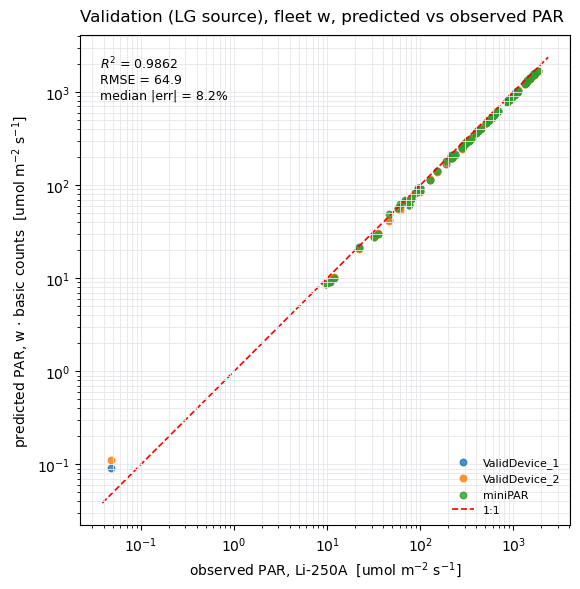

In [9]:
from pathlib import Path

coeffs = json.load(open('par_coeffs_fleet.json'))
w_fleet = pd.Series(coeffs['w'], index=coeffs['channels'])

VDATA = "../data/Validation_3_devces_LG/"
frames = []
for file in glob(f"{VDATA}/*.csv"):
    tdf = pd.read_csv(file).rename(columns={'atime': 'aint'})
    tdf['device'] = Path(file).stem.replace('multi_spec_readings_', '')
    frames.append(tdf)
vdf = pd.concat(frames, ignore_index=True)

obs = vdf.tia_par.to_numpy(float)
pred = basic_counts(vdf)[coeffs['channels']].to_numpy() @ w_fleet.to_numpy()

r2 = r2_score(obs, pred)
rmse = np.sqrt(mean_squared_error(obs, pred))
mape = float(np.median(np.abs(pred - obs) / obs) * 100)
print(f"Validation samples: {len(obs)}  ({vdf.device.nunique()} devices)")
print(f"  R^2 : {r2:.4g}")
print(f"  RMSE: {rmse:.4g}")
print(f"  median |err|: {mape:.2f}%")

lim = (0.8 * min(obs[obs > 0].min(), pred[pred > 0].min()),
       1.3 * max(obs.max(), pred.max()))

fig, ax = plt.subplots(figsize=(6.2, 6.0))
for dev_name, g in vdf.groupby('device'):
    ax.scatter(obs[g.index], pred[g.index], s=22, alpha=0.8, label=dev_name)
ax.plot(lim, lim, color='r', lw=1.2, ls='--', zorder=1, label='1:1')
ax.set(xscale='log', yscale='log',
       xlabel='observed PAR, Li-250A  [umol m$^{-2}$ s$^{-1}$]',
       ylabel='predicted PAR, w $\\cdot$ basic counts  [umol m$^{-2}$ s$^{-1}$]')
ax.set_title('Validation (LG source), fleet w, predicted vs observed PAR', loc='left', pad=10)
ax.set_aspect('equal')
ax.grid(True, which='both', color='#e5e7eb', lw=0.6, zorder=0)
ax.legend(frameon=False, loc='lower right', fontsize=8)
ax.annotate('$R^2$ = %.4f\nRMSE = %.1f\nmedian |err| = %.1f%%' % (r2, rmse, mape),
            xy=(0.04, 0.96), xycoords='axes fraction', va='top', fontsize=9)
fig.tight_layout()
plt.show()